In [ ]:
import sys

sys.path.insert(0, "..")

from configparser import ConfigParser

import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from src.core.models.multivar_gp.dense_gp import DenseGP
from src.utils.data_utils import load_aqsol_data

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)


def make_config(kernel="RBF", lmbda=0.01, alpha=1.0):
    cfg = ConfigParser()
    cfg["KERNEL"] = {"type": kernel, "lmbda": str(lmbda), "alpha": str(alpha)}
    cfg["SPARSE"] = {
        "use_sparse": "false",
        "num_inducing": "20",
        "inducing_method": "kmeans",
    }
    return cfg

# Limits of Gaussian Processes

GPs give exact posteriors and uncertainty. 

But these properties are enabled by the kernel, and **the kernel has a smoothness assumption that the data must actually satisfy**.

This notebook shows what happens when that assumption breaks.

## Smooth kernels vs discontinuities

The RBF kernel assumes the target is **real-analytic** (infinitely differentiable, equal to its Taylor series). The posterior mean lives in the RKHS $\mathcal{H}_k$, which for the RBF consists only of entire functions.

When the true function has a **jump discontinuity** (step function), a **kink** (absolute value), or a **discontinuous derivative** (piecewise linear), the GP posterior cannot represent the feature exactly. 

It has to approximate the non-smooth function with a smooth one. This means:

- **Overshoot / ringing** near discontinuities (analogous to [Gibbs phenomenon](https://en.wikipedia.org/wiki/Gibbs_phenomenon) in Fourier series)
- **Uncertainty overconfidence**: the model is confident in its wrong, smooth interpolation
- **No bandwidth param can fix**: see below: an RBF GP fitted to a step.

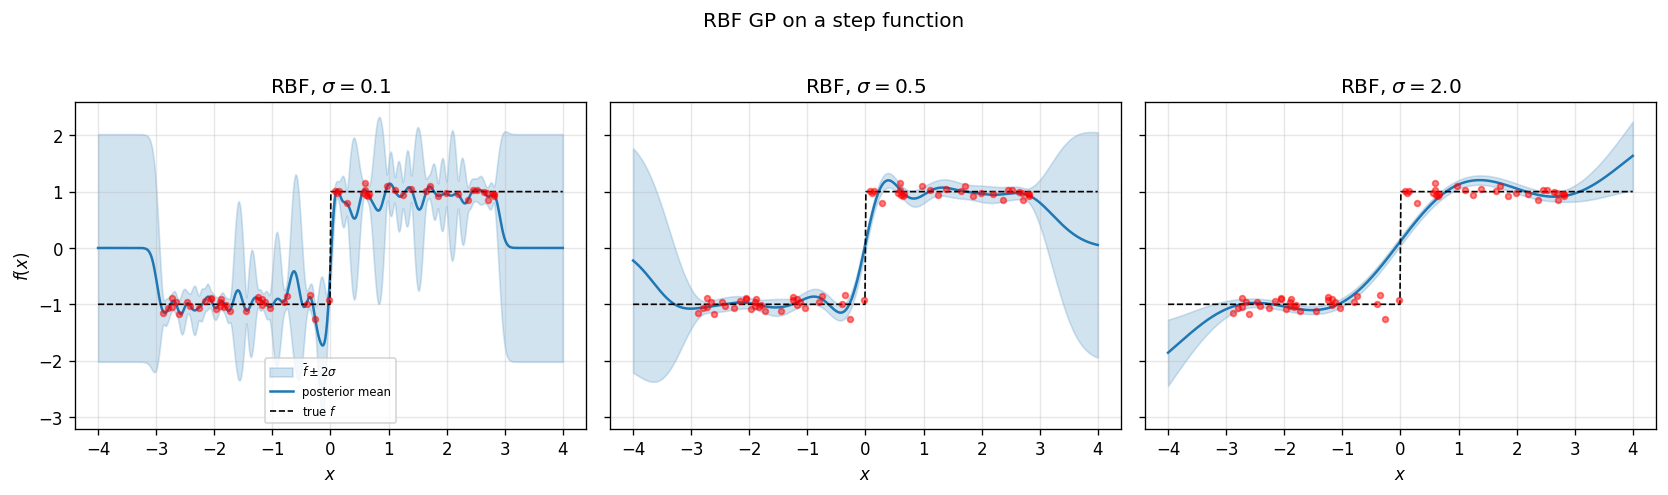

In [2]:
np.random.seed(42)

f_step = lambda x: np.where(x < 0, -1.0, 1.0)
noise_std = 0.1

X_train = np.sort(np.random.uniform(-3, 3, 60)).reshape(-1, 1)
y_train = f_step(X_train.ravel()) + noise_std * np.random.randn(len(X_train))
X_test = np.linspace(-4, 4, 500).reshape(-1, 1)

sigmas = [0.1, 0.5, 2.0]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, sig in zip(axes, sigmas):
    gp = DenseGP(make_config(lmbda=noise_std**2), np.array([sig]))
    gp.fit(X_train, y_train)
    mu, std = gp.predict(X_test, return_std=True)
    mu, std = np.asarray(mu), np.asarray(std)

    ax.fill_between(
        X_test.ravel(),
        mu - 2 * std,
        mu + 2 * std,
        alpha=0.2,
        color="C0",
        label=r"$\bar{f} \pm 2\sigma$",
    )
    ax.plot(X_test, mu, "C0", linewidth=1.5, label="posterior mean")
    ax.plot(X_test, f_step(X_test.ravel()), "k--", linewidth=1, label="true $f$")
    ax.scatter(X_train, y_train, c="red", s=12, zorder=5, alpha=0.5)
    ax.set_title(rf"RBF, $\sigma = {sig}$")
    ax.set_xlabel("$x$")

axes[0].set_ylabel("$f(x)$")
axes[0].legend(fontsize=7)
fig.suptitle("RBF GP on a step function", y=1.02)
plt.tight_layout()
plt.show()

No bandwidth or length scale will work!
- **Small $\sigma$**: oscillates everywhere, interpolates noise, ringing near the jump
- **Medium $\sigma$**: sigmoid-like transition, good when far from the jump but wrong near it
- **Large $\sigma$**: smears the discontinuity over a wide region, underestimates the jump magnitude

The issue is the **length scale is global** (stationary kernel). The function needs zero correlation length at $x = 0$ but infinite correlation length everywhere else. 

A single $\sigma$ cannot handle both.

## Spectral analysis

A step function has Fourier transform $\hat f(\omega) \propto 1/\omega$, it has large energy at **all frequencies**. The RKHS norm is:

$$\|f\|_{\mathcal{H}_k}^2 = \int \frac{|\hat f(\omega)|^2}{\hat\psi(\omega)} \, d\omega$$

In the RBF kernel, $\hat\psi(\omega) \propto e^{-\ell^2\|\omega\|^2/2}$ decays super-exponentially. So $1/\hat\psi$ grows super-exponentially, and the integral diverges for a step function: **the step function has infinite RKHS norm**. 

It does not live in the space of functions the GP considers possible.

The posterior mean is the projection of the step function onto $\mathcal{H}_k$, minimising the regularised objective. This projection must be smooth, so it rounds the jump off. Near the discontinuity, the GP is doing the best it can within its function space, but the space itself is wrong.

For Matérn-$\nu$, $\hat\psi(\omega) \sim \|\omega\|^{-(2\nu+d)}$ (polynomial decay). The RKHS norm of a step function is finite *iff* $\int |\omega|^{2\nu+1} \cdot |\omega|^{-2} \, d\omega < \infty$ near $\omega = 0$ and converges at $\infty$. For the step function ($|\hat f| \sim 1/|\omega|$), this requires $2\nu - 1 < -1$, i.e. $\nu < 0$. 

No standard Matérn can represent the step function exactly, but lower $\nu$ reduces the penalty on high-frequency components and gives a sharper transition.

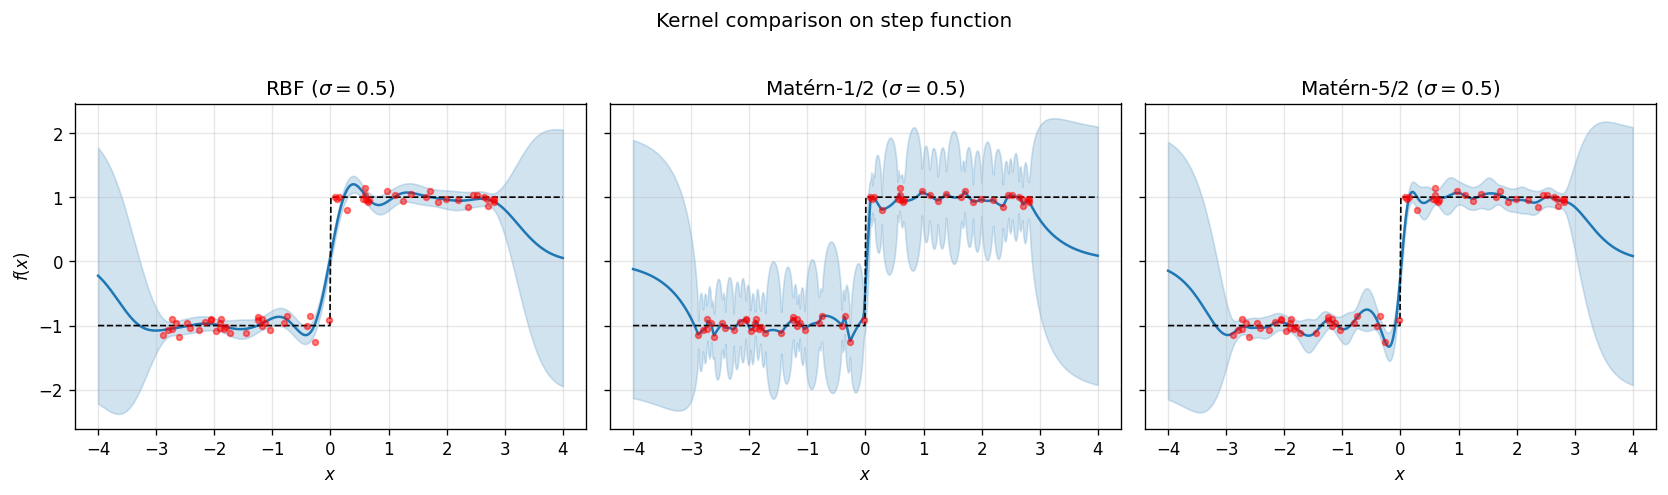

In [3]:
kernels = [
    ("RBF", 0.5, None, "RBF ($\\sigma = 0.5$)"),
    ("MATERN", 0.5, 0.5, "Matérn-1/2 ($\\sigma = 0.5$)"),
    ("MATERN", 0.5, 2.5, "Matérn-5/2 ($\\sigma = 0.5$)"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (ktype, sig, alpha, title) in zip(axes, kernels):
    cfg = make_config(kernel=ktype, lmbda=noise_std**2, alpha=alpha or 1.0)
    gp = DenseGP(cfg, np.array([sig]))
    gp.fit(X_train, y_train)
    mu, std = gp.predict(X_test, return_std=True)
    mu, std = np.asarray(mu), np.asarray(std)

    ax.fill_between(
        X_test.ravel(),
        mu - 2 * std,
        mu + 2 * std,
        alpha=0.2,
        color="C0",
    )
    ax.plot(X_test, mu, "C0", linewidth=1.5)
    ax.plot(X_test, f_step(X_test.ravel()), "k--", linewidth=1)
    ax.scatter(X_train, y_train, c="red", s=12, zorder=5, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel("$x$")

axes[0].set_ylabel("$f(x)$")
fig.suptitle("Kernel comparison on step function", y=1.02)
plt.tight_layout()
plt.show()

Matérn-1/2 (exponential kernel) gives the sharpest transition since it amidts non-differentiable functions. 

Its sample paths are continuous but nowhere differentiable, so it doesn't try to smooth out the jump as aggressively. However it still can't represent the true discontinuity (continuous functions can't step).

So in the Matérn kernel family, lower $\nu$ helps with sharp features, but no GP with a continuous kernel can truly represent discontinuities.

In [ ]:
# A more realistic challenge: piecewise function with a kink and a jump
def f_piecewise(x):
    y = np.zeros_like(x)
    y[x < -1] = -0.5 * x[x < -1] - 1.5  # linear
    y[(x >= -1) & (x < 1)] = np.sin(2 * x[(x >= -1) & (x < 1)])  # smooth
    y[x >= 1] = 0.5 * x[x >= 1] ** 2 - 0.5  # quadratic, jump at x=1
    return y


np.random.seed(0)
X_pw = np.sort(np.random.uniform(-3, 3, 80)).reshape(-1, 1)
y_pw = f_piecewise(X_pw.ravel()) + 0.1 * np.random.randn(len(X_pw))
X_pw_test = np.linspace(-3.5, 3.5, 500).reshape(-1, 1)

kernels_pw = [
    ("RBF", 0.5, None, "RBF"),
    ("MATERN", 0.5, 0.5, "Matérn-1/2"),
    ("MATERN", 0.5, 2.5, "Matérn-5/2"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (ktype, sig, alpha, title) in zip(axes, kernels_pw):
    cfg = make_config(kernel=ktype, lmbda=0.01, alpha=alpha or 1.0)
    gp = DenseGP(cfg, np.array([sig]))
    gp.fit(X_pw, y_pw)
    mu, std = gp.predict(X_pw_test, return_std=True)
    mu, std = np.asarray(mu), np.asarray(std)

    ax.fill_between(
        X_pw_test.ravel(),
        mu - 2 * std,
        mu + 2 * std,
        alpha=0.2,
        color="C0",
    )
    ax.plot(X_pw_test, mu, "C0", linewidth=1.5)
    ax.plot(X_pw_test, f_piecewise(X_pw_test.ravel()), "k--", linewidth=1)
    ax.scatter(X_pw, y_pw, c="red", s=12, zorder=5, alpha=0.5)
    # mark the breakpoints
    for bp in [-1, 1]:
        ax.axvline(bp, color="grey", ls=":", alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel("$x$")

axes[0].set_ylabel("$f(x)$")
fig.suptitle("Piecewise function: kink at $x=-1$, jump at $x=1$", y=1.02)
plt.tight_layout()
plt.show()

In the smooth region of the piecewise example ($-1 < x < 1$), the GP does well. However, looking at the segment boundaries:

- At $x = -1$ (kink): all kernels smooth the corner. RBF does it more, Matérn less.
- At $x = 1$ (jump): the GP interpolates through the discontinuity. The smooth region "leaks" into the quadratic region and vice versa. The uncertainty bands do not widen at the breakpoints, so the model is confident in its (wrong) smooth interpolation.

## Tree-based models for discontinuitties

Decision trees partition the input space into **axis-aligned rectangles** and fit a constant (or simple model) in each. 

Discontinuities along axis-aligned boundaries can be fitted by trees easily:

- A split at $x = 0$ perfectly recovers the step function
- Ensemble methods (random forests, gradient boosting) combine many trees to approximate smooth functions too
- No smoothness assumption is baked in; the space includes piecewise-constant functions

The tradeoffs:

| | GP | Tree ensemble |
|---|---|---|
| **Smoothness** | Built-in via kernel | Emergent from averaging many step functions |
| **Discontinuities** | Nope | Native |
| **Uncertainty** | Analytic (posterior variance) | Heuristic (variance across trees) |
| **Extrapolation** | Reverts to prior (honest about ignorance) | Predicts last seen value (uncommunicative failure) |
| **Scalability** | $\mathcal{O}(n^3)$ or $\mathcal{O}(nm^2)$ sparse | $\mathcal{O}(n \log n)$ per tree |

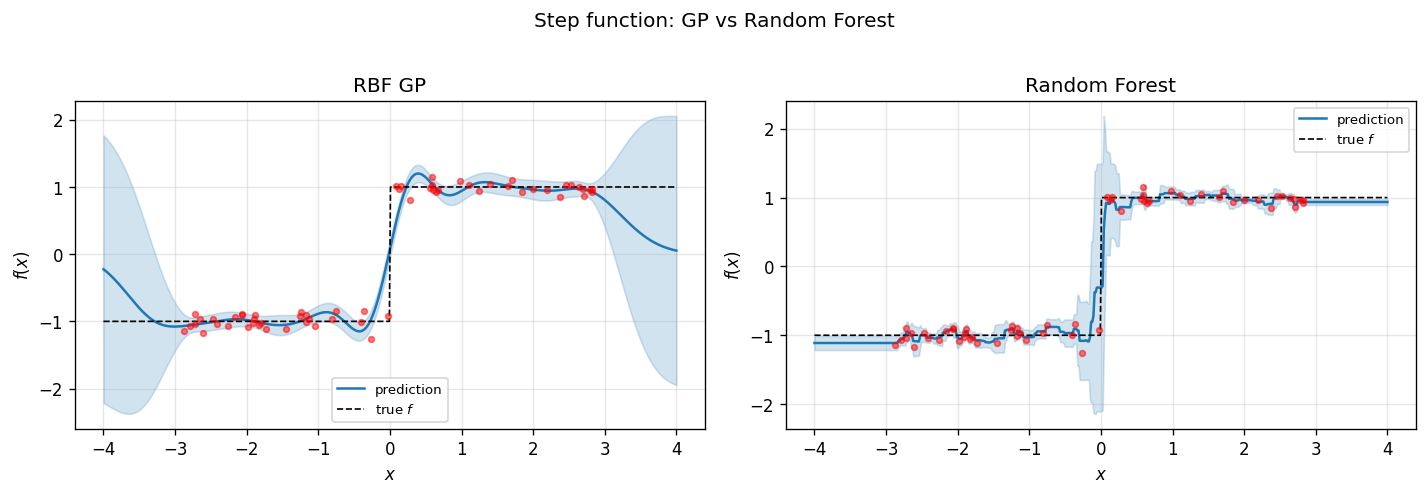

MSE; GP: 0.1000, Random Forest: 0.0182


In [5]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
mu_rf = rf.predict(X_test)

# Tree uncertainty: std. dev. across individual tree predictions
tree_preds = np.array([t.predict(X_test) for t in rf.estimators_])
std_rf = tree_preds.std(axis=0)

gp_rbf = DenseGP(make_config(lmbda=noise_std**2), np.array([0.5]))
gp_rbf.fit(X_train, y_train)
mu_gp, std_gp = gp_rbf.predict(X_test, return_std=True)
mu_gp, std_gp = np.asarray(mu_gp), np.asarray(std_gp)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, mu, std, title in [
    (axes[0], mu_gp, std_gp, "RBF GP"),
    (axes[1], mu_rf, std_rf, "Random Forest"),
]:
    ax.fill_between(
        X_test.ravel(),
        mu - 2 * std,
        mu + 2 * std,
        alpha=0.2,
        color="C0",
    )
    ax.plot(X_test, mu, "C0", linewidth=1.5, label="prediction")
    ax.plot(X_test, f_step(X_test.ravel()), "k--", linewidth=1, label="true $f$")
    ax.scatter(X_train, y_train, c="red", s=12, zorder=5, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$f(x)$")
    ax.legend(fontsize=8)

fig.suptitle("Step function: GP vs Random Forest", y=1.02)
plt.tight_layout()
plt.show()

mse_gp = np.mean((f_step(X_test.ravel()) - mu_gp) ** 2)
mse_rf = np.mean((f_step(X_test.ravel()) - mu_rf) ** 2)
print(f"MSE; GP: {mse_gp:.4f}, Random Forest: {mse_rf:.4f}")

The random forest handles the step, (a single split works). The GP smooths across it. However:

- The RF "uncertainty" (inter-tree variance) is a heuristic, not a posterior. It does not widen at the extrapolation boundary $|x| > 3$ the way the GP's posterior variance does.
- The RF prediction is piecewise constant (staircase), which is visible as small steps in the otherwise flat regions. With enough trees and data, this is negligible.

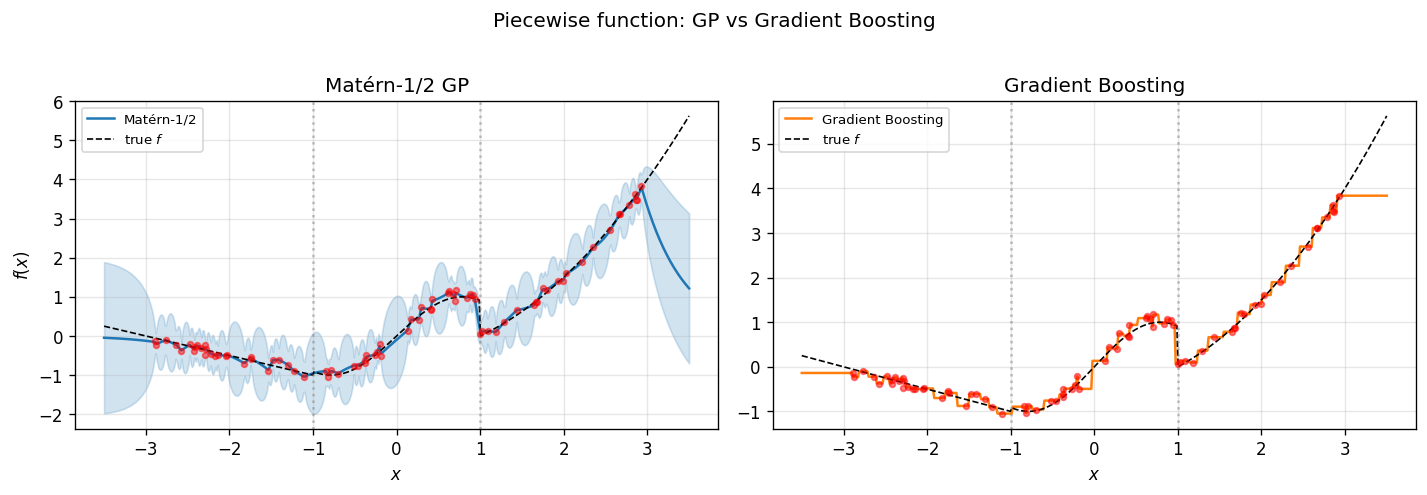

MSE; Matérn-1/2: 0.6313,  Gradient Boosting: 0.1033


In [6]:
gb = GradientBoostingRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42
)
gb.fit(X_pw, y_pw)
mu_gb = gb.predict(X_pw_test)

gp_m12 = DenseGP(make_config(kernel="MATERN", lmbda=0.01, alpha=0.5), np.array([0.5]))
gp_m12.fit(X_pw, y_pw)
mu_m12, std_m12 = gp_m12.predict(X_pw_test, return_std=True)
mu_m12, std_m12 = np.asarray(mu_m12), np.asarray(std_m12)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.fill_between(
    X_pw_test.ravel(),
    mu_m12 - 2 * std_m12,
    mu_m12 + 2 * std_m12,
    alpha=0.2,
    color="C0",
)
ax.plot(X_pw_test, mu_m12, "C0", linewidth=1.5, label="Matérn-1/2")
ax.plot(X_pw_test, f_piecewise(X_pw_test.ravel()), "k--", linewidth=1, label="true $f$")
ax.scatter(X_pw, y_pw, c="red", s=12, zorder=5, alpha=0.5)
for bp in [-1, 1]:
    ax.axvline(bp, color="grey", ls=":", alpha=0.5)
ax.set_title("Matérn-1/2 GP")
ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(X_pw_test, mu_gb, "C1", linewidth=1.5, label="Gradient Boosting")
ax.plot(X_pw_test, f_piecewise(X_pw_test.ravel()), "k--", linewidth=1, label="true $f$")
ax.scatter(X_pw, y_pw, c="red", s=12, zorder=5, alpha=0.5)
for bp in [-1, 1]:
    ax.axvline(bp, color="grey", ls=":", alpha=0.5)
ax.set_title("Gradient Boosting")
ax.set_xlabel("$x$")
ax.legend(fontsize=8)

fig.suptitle("Piecewise function: GP vs Gradient Boosting", y=1.02)
plt.tight_layout()
plt.show()

y_true_pw = f_piecewise(X_pw_test.ravel())
print(
    f"MSE; Matérn-1/2: {np.mean((y_true_pw - mu_m12) ** 2):.4f},  "
    f"Gradient Boosting: {np.mean((y_true_pw - mu_gb) ** 2):.4f}"
)

## Extrapolation

Trees fail silently outside range seen in fitting. They predict the value of the nearest leaf, giving constant extrapolation or clamping without warning. 

GPs revert to the prior mean with growing uncertainty, which is honest and communicative.

Below: both models trained on $x \in [-2, 2]$, queried on $[-5, 5]$.

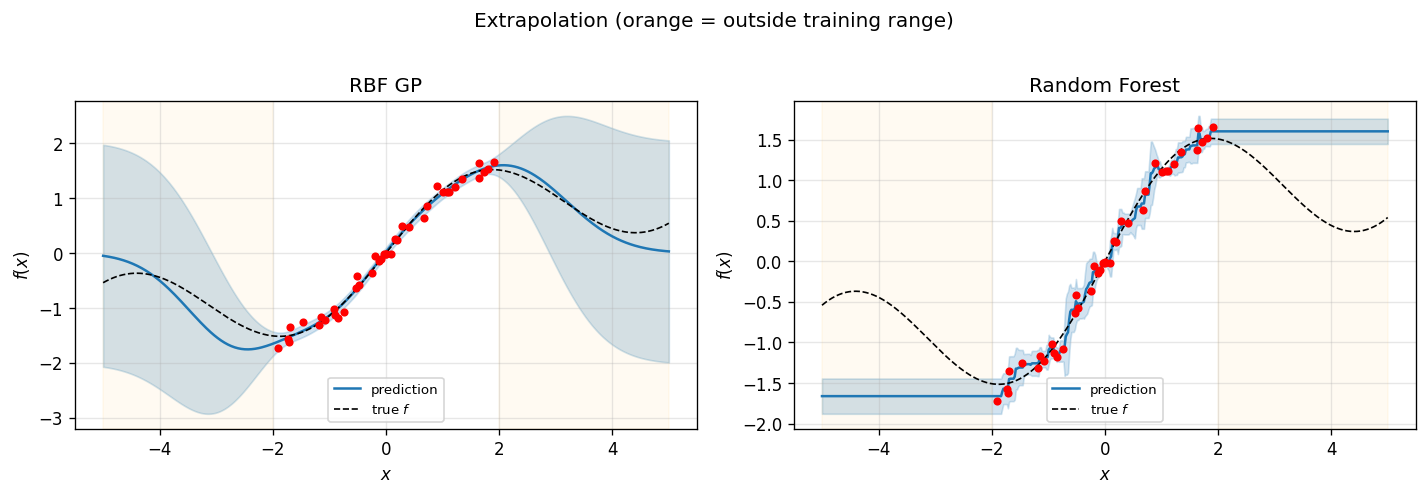

In [7]:
np.random.seed(7)
f_smooth = lambda x: np.sin(x) + 0.3 * x

X_tr_ext = np.sort(np.random.uniform(-2, 2, 40)).reshape(-1, 1)
y_tr_ext = f_smooth(X_tr_ext.ravel()) + 0.1 * np.random.randn(len(X_tr_ext))
X_te_ext = np.linspace(-5, 5, 500).reshape(-1, 1)

# GP
gp_ext = DenseGP(make_config(lmbda=0.01), np.array([1.0]))
gp_ext.fit(X_tr_ext, y_tr_ext)
mu_ext, std_ext = gp_ext.predict(X_te_ext, return_std=True)
mu_ext, std_ext = np.asarray(mu_ext), np.asarray(std_ext)

# RF
rf_ext = RandomForestRegressor(n_estimators=100, random_state=42)
rf_ext.fit(X_tr_ext, y_tr_ext)
mu_rf_ext = rf_ext.predict(X_te_ext)
tree_preds_ext = np.array([t.predict(X_te_ext) for t in rf_ext.estimators_])
std_rf_ext = tree_preds_ext.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, mu, std, title in [
    (axes[0], mu_ext, std_ext, "RBF GP"),
    (axes[1], mu_rf_ext, std_rf_ext, "Random Forest"),
]:
    ax.fill_between(
        X_te_ext.ravel(),
        mu - 2 * std,
        mu + 2 * std,
        alpha=0.2,
        color="C0",
    )
    ax.plot(X_te_ext, mu, "C0", linewidth=1.5, label="prediction")
    ax.plot(X_te_ext, f_smooth(X_te_ext.ravel()), "k--", linewidth=1, label="true $f$")
    ax.scatter(X_tr_ext, y_tr_ext, c="red", s=15, zorder=5)
    ax.axvspan(-5, -2, alpha=0.05, color="orange")
    ax.axvspan(2, 5, alpha=0.05, color="orange")
    ax.set_title(title)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$f(x)$")
    ax.legend(fontsize=8)

fig.suptitle(
    "Extrapolation (orange = outside training range)",
    y=1.02,
)
plt.tight_layout()
plt.show()

The GP's uncertainty grows in the extrapolation region (orange), communicating that predictions there are unreliable. The RF clamps with no increase in variance, it's uncertainty is false here.

## AqSolDB: GP vs trees

Molecular solubility is a function of many descriptors, with potentially non-smooth relationships (e.g. phase transitions, structural thresholds).

In [8]:
X_aq, y_aq, feature_names, scaler = load_aqsol_data(
    csv_path="../data/solubility-dataset.csv", scale=True, return_scaler=True
)
X_aq, y_aq = np.asarray(X_aq), np.asarray(y_aq)

# Subsample because hate O(n^3)
np.random.seed(42)
n_sub = 2000
idx = np.random.choice(len(X_aq), n_sub, replace=False)
X_sub, y_sub = X_aq[idx], y_aq[idx]

X_tr, X_te, y_tr, y_te = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42)
d = X_tr.shape[1]

results = {}

# RBF GP
gp_rbf_aq = DenseGP(make_config(lmbda=0.1), np.ones(d))
gp_rbf_aq.fit(X_tr, y_tr)
pred_rbf = np.asarray(gp_rbf_aq.predict(X_te))
results["RBF GP"] = (mean_squared_error(y_te, pred_rbf), r2_score(y_te, pred_rbf))

# Matern-1/2 GP
gp_m12_aq = DenseGP(make_config(kernel="MATERN", lmbda=0.1, alpha=0.5), np.ones(d))
gp_m12_aq.fit(X_tr, y_tr)
pred_m12 = np.asarray(gp_m12_aq.predict(X_te))
results["Matérn-1/2 GP"] = (
    mean_squared_error(y_te, pred_m12),
    r2_score(y_te, pred_m12),
)

# Random Forest
rf_aq = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
rf_aq.fit(X_tr, y_tr)
pred_rf = rf_aq.predict(X_te)
results["Random Forest"] = (mean_squared_error(y_te, pred_rf), r2_score(y_te, pred_rf))

# Gradient Boosting
gb_aq = GradientBoostingRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.1, random_state=42
)
gb_aq.fit(X_tr, y_tr)
pred_gb = gb_aq.predict(X_te)
results["Gradient Boosting"] = (
    mean_squared_error(y_te, pred_gb),
    r2_score(y_te, pred_gb),
)

print(f"{'Model':<20} {'MSE':>8} {'R²':>8}")
print("-" * 38)
for name, (mse, r2) in results.items():
    print(f"{name:<20} {mse:>8.4f} {r2:>8.4f}")

Model                     MSE       R²
--------------------------------------
RBF GP                 4.1400   0.2731
Matérn-1/2 GP          3.0417   0.4659
Random Forest          1.4370   0.7477
Gradient Boosting      1.5124   0.7344


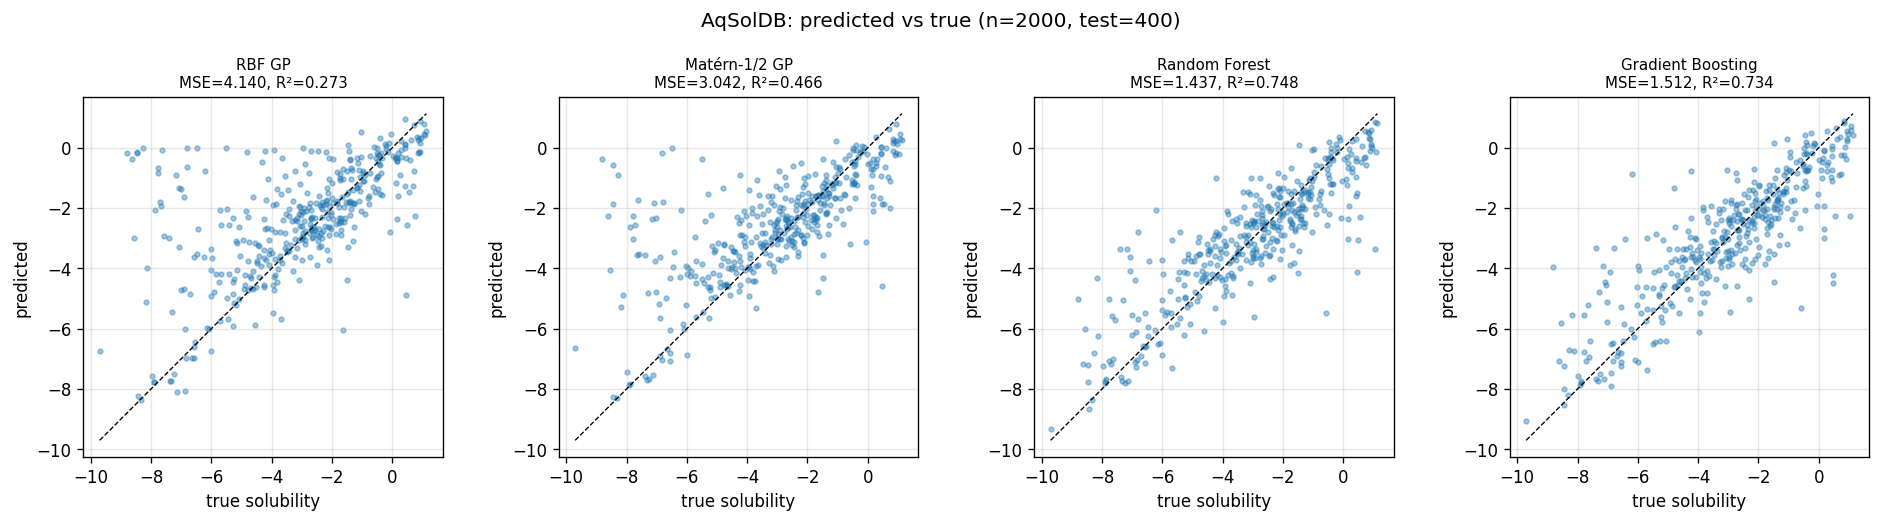

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
preds = [
    ("RBF GP", pred_rbf),
    ("Matérn-1/2 GP", pred_m12),
    ("Random Forest", pred_rf),
    ("Gradient Boosting", pred_gb),
]

for ax, (name, pred) in zip(axes, preds):
    mse, r2 = results[name]
    ax.scatter(y_te, pred, s=8, alpha=0.4, c="C0")
    lims = [min(y_te.min(), pred.min()), max(y_te.max(), pred.max())]
    ax.plot(lims, lims, "k--", linewidth=0.8)
    ax.set_xlabel("true solubility")
    ax.set_ylabel("predicted")
    ax.set_title(f"{name}\nMSE={mse:.3f}, R²={r2:.3f}", fontsize=9)
    ax.set_aspect("equal")

fig.suptitle(f"AqSolDB: predicted vs true (n={n_sub}, test={len(y_te)})", y=1.03)
plt.tight_layout()
plt.show()

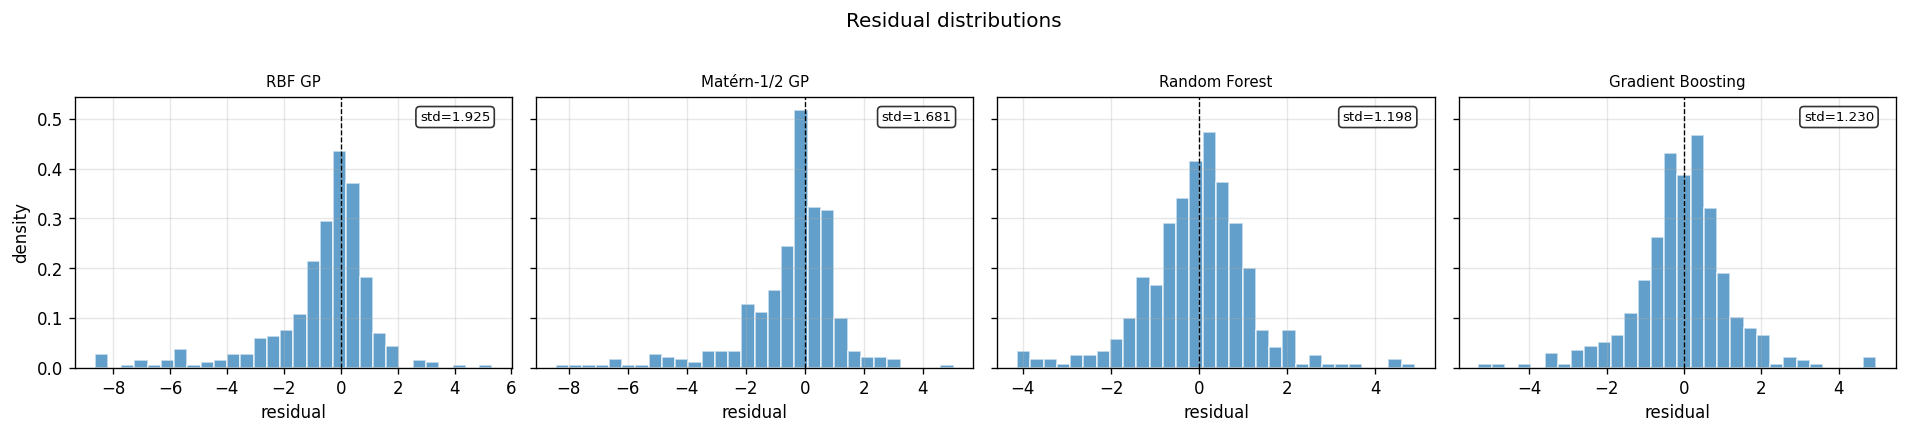

In [10]:
# Residuals
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)

for ax, (name, pred) in zip(axes, preds):
    residuals = y_te - pred
    ax.hist(residuals, bins=30, density=True, alpha=0.7, color="C0", edgecolor="white")
    ax.axvline(0, color="k", ls="--", lw=0.8)
    ax.set_xlabel("residual")
    ax.set_title(name, fontsize=9)
    ax.text(
        0.95,
        0.95,
        f"std={residuals.std():.3f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8),
    )

axes[0].set_ylabel("density")
fig.suptitle("Residual distributions", y=1.02)
plt.tight_layout()
plt.show()

- Tree ensembles generally outperform GPs on this dataset, suggesting the solubility surface has non-smooth features (structural thresholds, discrete molecular properties) that trees handle better
- Matérn-1/2 may outperform RBF, consistent with the rougher RKHS being better
- The GP uses default (non-optimised) hyperparams here. With proper marginal likelihood optimisation (ARD length scales), the gap might narrow. But the GP function class inherently cannot represent discontinuities